<a href="https://colab.research.google.com/github/b-karapet/colab-notebooks/blob/main/Brute_Force_with_SIFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python

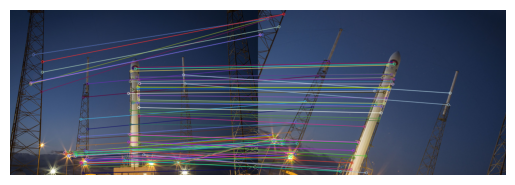

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

sift = cv2.SIFT_create()

img1 = cv2.imread("sample_data/img5.png")
img2 = cv2.imread("sample_data/img6.png")

kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append([m])

img3 = cv2.drawMatchesKnn(
    img1, kp1, img2, kp2, good, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))   # convert BGR to RGB for display
plt.axis("off")
plt.show()